<a href="https://colab.research.google.com/github/yashita-mishra/IML-Assignment-2/blob/main/A2Q1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
from scipy.optimize import minimize, Bounds, LinearConstraint
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_breast_cancer
from datasets import load_dataset

In [ ]:
class softmarginsvm:
  def __init__(self, C=1.0, tol=1e-5, max_iter=300):
    self.C = float(C)
    self.tol = tol
    self.max_iter = max_iter
  def fit(self, X, y, verbose=False):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).ravel()
    n = X.shape[0]
    K = X @ X.T
    Q = (y[:, None] * y[None, :]) * K
    def obj(a) :
      return 0.5 * a @ Q @ a - a.sum()
    def grad(a) :
      return Q @ a - 1.0
    bounds = Bounds(lb=np.zeros(n), ub=self.C * np.ones(n))
    eq_constraint = LinearConstraint(y[None, :], 0.0, 0.0)
    alpha0 = np.zeros(n)
    res = minimize(
        obj, alpha0, jac=grad,
        bounds=bounds, constraints=eq_constraint,
        method="SLSQP",
        options={"maxiter": self.max_iter, "ftol": 1e-9, "disp": verbose},
    )
    alpha = res.x
    alpha[alpha < 0] = 0.0
    svmask = alpha > self.tol
    marginsvmask = (alpha > self.tol) & (alpha < self.C - self.tol)
    self.W = (alpha*y) @ X
    if marginsvmask.any():
      self.b = np.mean(y[marginsvmask] - X[marginsvmask] @ self.W)
    elif svmask.any():
      self.b = np.mean(y[svmask] - X[svmask] @ self.W)
    else:
      self.b = 0.0
    self.alpha = alpha
    self.svmask = svmask
    self.marginsvmask = marginsvmask
    self.support_vectors_ = X[svmask]
    self.support_alphas_ = alpha[svmask]
    self.support_y_ = y[svmask]
    self.optim_result_ = res
    return self

  def decision_function(self, X):
      return X @ self.W + self.b
  def predict(self, X):
      return np.sign(self.decision_function(X)).astype(int)

In [ ]:
def stand(X_train, X_test):
  mu = X_train.mean(axis=0)
  sd = X_train.std(axis=0)
  sd[sd == 0] = 1.0
  return (X_train - mu) / sd, (X_test - mu) / sd
def train_test_split_np(X, y, test_size = 0.25, seed = 0):
  range = np.random.default_rng(seed)
  idx = range.permutation(len(X))
  n_te = int(round(test_size * len(X)))
  te, tr = idx[:n_te], idx[n_te:]
  return X[tr], X[te], y[tr], y[te]

In [ ]:
def get_breast_cancer_as_df():
    data = load_breast_cancer()
    df = pd.DataFrame(data.data, columns=data.feature_names)
    y_pd = data.target.copy()
    y_pd[y_pd == 0] = -1
    return df.values, y_pd, list(data.feature_names)

X, y, feat_cols = get_breast_cancer_as_df()
print(f"X={X.shape}, y={y.shape}, +1: {(y==1).sum()}, -1: {(y==-1).sum()}")
Xtr, Xte, ytr, yte = train_test_split_np(X, y, test_size=0.25, seed=0)
Xtr, Xte = stand(Xtr, Xte)
Cs = [0.01, 0.1, 1.0, 10.0]
train_acc, test_acc, n_sv, n_margin_sv = [], [], [], []
for C in Cs:
    svm = softmarginsvm(C=C).fit(Xtr, ytr)
    train_acc.append((svm.predict(Xtr) == ytr).mean())
    test_acc.append((svm.predict(Xte)  == yte).mean())
    n_sv.append(int(svm.svmask.sum()))
    n_margin_sv.append(int(svm.marginsvmask.sum()))
    print(f"C={C:<6g}  train={train_acc[-1]:.4f}  test={test_acc[-1]:.4f}  "
    f" SV = {n_sv[-1]} margin-SV = {n_margin_sv[-1]}")

X=(569, 30), y=(569,), +1: 357, -1: 212
C=0.01    train=0.9625  test=0.9437   SV = 95 margin-SV = 7
C=0.1     train=0.9836  test=0.9648   SV = 51 margin-SV = 11
C=1       train=0.9883  test=0.9718   SV = 34 margin-SV = 17
C=10      train=0.9906  test=0.9789   SV = 29 margin-SV = 20


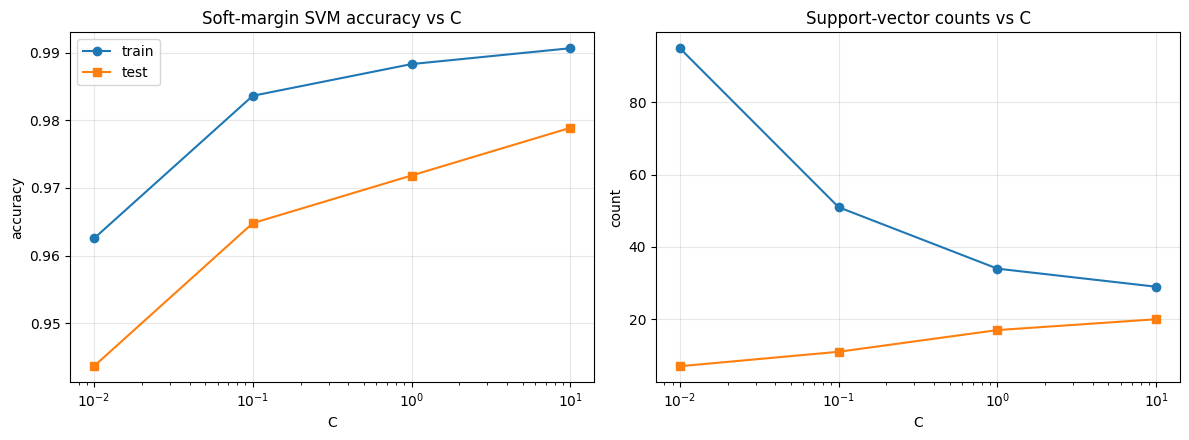

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].plot(Cs, train_acc, "o-", label="train")
ax[0].plot(Cs, test_acc,  "s-", label="test")
ax[0].set_xscale("log"); ax[0].set_xlabel("C"); ax[0].set_ylabel("accuracy")
ax[0].set_title("Soft-margin SVM accuracy vs C"); ax[0].grid(alpha=.3); ax[0].legend()
ax[1].plot(Cs, n_sv,        "o-", label="all SVs")
ax[1].plot(Cs, n_margin_sv, "s-", label="margin SVs")
ax[1].set_xscale("log"); ax[1].set_xlabel("C"); ax[1].set_ylabel("count")
ax[1].set_title("Support-vector counts vs C"); ax[1].grid(alpha=.3); ax[1].legend
plt.tight_layout()
plt.savefig("svm_breast_cancer.png", dpi=150, bbox_inches="tight")
plt.show()